/home/tine/miniconda3/envs/mlmarker/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


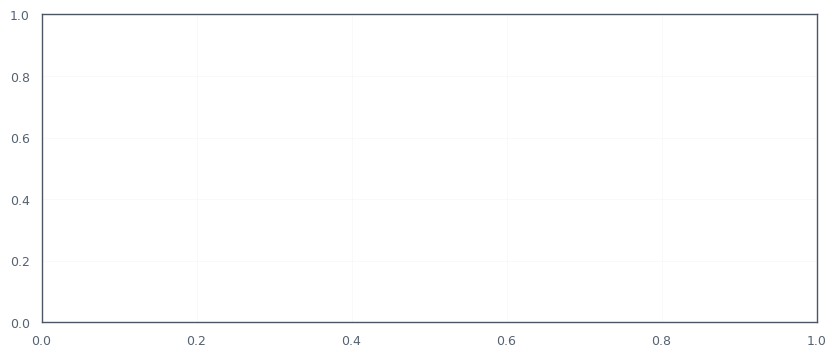

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import pickle
import umap

import mlmarker
from mlmarker.model import MLMarker
from plotly.subplots import make_subplots
import plotly.graph_objects as go

sns.set(style="whitegrid")

import sys
sys.path.append('/home/tine/git/Publication/MLMarker-manuscript/Figures_review')
from manuscript_style import apply_style, COLORS, FIGURE_SIZES, get_categorical_colors

apply_style()

# Use in your plots
# plt.plot(x, y, color=COLORS['primary'])
colors = get_categorical_colors(5)  # Get 5 colors for groups
fig, ax = plt.subplots(figsize=FIGURE_SIZES['double'])
from manuscript_style import COLORS, add_title, style_legend
sys.path.append('/home/tine/git/Publication/MLMarker-manuscript')
import tqdm
sys.path.append('/home/compomics/git/Projects/MLMarker_paper')
from MLMarker_reprocessing_quant import *
lengths_path = "/home/tine/git/Publication/MLMarker-manuscript/uniprot_reviewed_lengths.tsv"


NameError: name 'mlmarker_df' is not defined

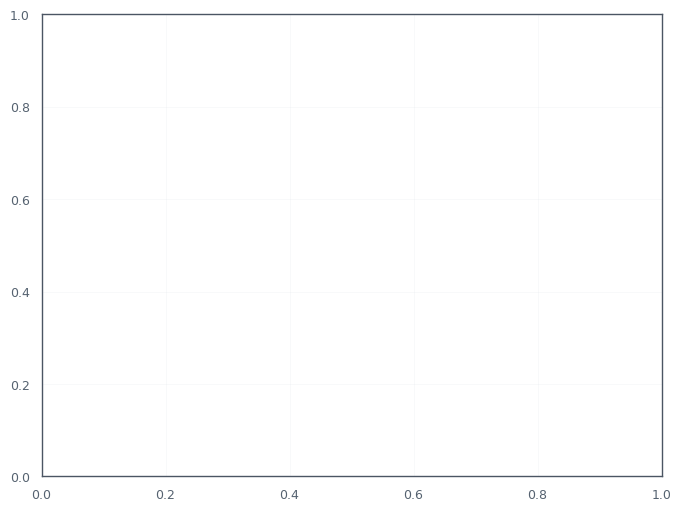

In [2]:
# Study: Do poor responders have significantly higher brain similarity?
from manuscript_style import COLORS, add_title, style_legend

fig, ax = plt.subplots(figsize=(8, 6))

# Create boxplot with manuscript colors
box_colors = [COLORS['teal'], COLORS['teal']]  # green for good, red for poor
sns_plot = sns.boxplot(
    data=mlmarker_df, x='disease_status', y='Brain', 
    palette={'good': COLORS['teal'], 'poor': COLORS['teal']},
    order=['good', 'poor'],
    ax=ax
)

# Overlay individual data points
sns.stripplot(
    data=mlmarker_df, x='disease_status', y='Brain',
    color=COLORS['dark_gray'], alpha=0.6, size=6,
    order=['good', 'poor'],
    ax=ax
)

# Add the number of samples to the x-axis label
for i, status in enumerate(['good', 'poor']):
    count = (mlmarker_df['disease_status'] == status).sum()
    plt.text(i, mlmarker_df['Brain'].min() - 0.02, f"n={count}", ha='center', va='top', fontsize=10)


plt.title('Brain Prediction Score by Response Status', fontweight='bold')
plt.ylabel('Brain Prediction Score')
plt.xlabel('Response Status')
#save figure
plt.savefig('/home/tine/git/Publication/MLMarker-manuscript/Figures_review/Fig2a.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Statistical comparison - test if POOR > GOOD (one-sided)
print("=" * 60)
print("HYPOTHESIS TEST: Do poor responders have higher brain similarity?")
print("=" * 60)

good_samples = mlmarker_df[mlmarker_df['disease_status'] == 'good']['Brain']
poor_samples = mlmarker_df[mlmarker_df['disease_status'] == 'poor']['Brain']

print(f"\nDescriptive Statistics:")
print(f"  Good responders: mean={good_samples.mean():.4f}, std={good_samples.std():.4f}, n={len(good_samples)}")
print(f"  Poor responders: mean={poor_samples.mean():.4f}, std={poor_samples.std():.4f}, n={len(poor_samples)}")
print(f"  Difference (poor - good): {poor_samples.mean() - good_samples.mean():.4f}")

# Check normality
print(f"\nNormality Tests (Shapiro-Wilk):")
good_normality = shapiro(good_samples)
poor_normality = shapiro(poor_samples)
print(f"  Good responders: W={good_normality.statistic:.3f}, p={good_normality.pvalue:.4f}")
print(f"  Poor responders: W={poor_normality.statistic:.3f}, p={poor_normality.pvalue:.4f}")

# One-sided test: H1: poor > good (alternative='greater' when poor is first)
print(f"\nStatistical Tests (one-sided: poor > good):")

# Mann-Whitney U test (non-parametric, more robust)
stat_mw, p_value_mw_two = mannwhitneyu(poor_samples, good_samples, alternative='two-sided')
stat_mw, p_value_mw_one = mannwhitneyu(poor_samples, good_samples, alternative='greater')
print(f"  Mann-Whitney U: U={stat_mw:.1f}")
print(f"    Two-sided p-value: {p_value_mw_two:.4f}")
print(f"    One-sided p-value (poor > good): {p_value_mw_one:.4f}")

# T-test (for comparison)
stat_t, p_value_t_two = ttest_ind(poor_samples, good_samples, equal_var=False)
p_value_t_one = p_value_t_two / 2 if stat_t > 0 else 1 - p_value_t_two / 2
print(f"  Welch's t-test: t={stat_t:.3f}")
print(f"    Two-sided p-value: {p_value_t_two:.4f}")
print(f"    One-sided p-value (poor > good): {p_value_t_one:.4f}")

# Conclusion
print(f"\n" + "=" * 60)
print("CONCLUSION:")
if p_value_mw_one < 0.05:
    print(f"  ✓ SIGNIFICANT: Poor responders have significantly HIGHER")
    print(f"    brain similarity scores (p = {p_value_mw_one:.4f})")
elif p_value_mw_one < 0.1:
    print(f"  ~ TREND: Poor responders tend to have higher brain similarity")
    print(f"    scores, but not statistically significant (p = {p_value_mw_one:.4f})")
else:
    print(f"  ✗ NOT SIGNIFICANT: No evidence that poor responders have")
    print(f"    higher brain similarity scores (p = {p_value_mw_one:.4f})")
print("=" * 60)

## Custom Visualization Functions

In [ ]:
def visualise_custom_plot(df):
    """
    Create grouped barplot of total protein contributions by tissue.
    """
    # Aggregate positive and negative contributions per tissue
    positive_totals = df.clip(lower=0).sum(axis=1)
    negative_totals = df.clip(upper=0).abs().sum(axis=1)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=df.index,
        y=positive_totals,
        name="Positive Contributions",
        marker_color='green',
        hoverinfo='x+y',
    ))
    fig.add_trace(go.Bar(
        x=df.index,
        y=negative_totals,
        name="Negative Contributions",
        marker_color='red',
        hoverinfo='x+y',
    ))
    fig.update_layout(
        barmode='group',
        title='Grouped Barplot of Total Protein Contributions by Tissue',
        xaxis_title='Tissues',
        yaxis_title='Total Contributions',
        xaxis=dict(tickangle=-45),
        template="plotly_white"
    )
    fig.show()

In [ ]:
def visualise_custom_tissue_plot(df, tissue_name):
    """
    Create detailed visualization for a specific tissue.
    """
    df = df.loc[[tissue_name]]
    positive_contributions = df.clip(lower=0)
    negative_contributions = df.clip(upper=0).abs()

    threshold = 0.001
    positive_main = positive_contributions.loc[:, (positive_contributions > threshold).any()]
    positive_others = positive_contributions.loc[:, (positive_contributions <= threshold).all()].sum(axis=1)
    negative_main = negative_contributions.loc[:, (negative_contributions > threshold).any()]
    negative_others = negative_contributions.loc[:, (negative_contributions <= threshold).all()].sum(axis=1)

    # Retrieve protein information
    protein_data = []
    for protein in positive_main.columns.union(negative_main.columns):
        try:
            protein_info = mlmarker.explainability.get_protein_info(protein)
            value = positive_main.get(protein, pd.Series(0)).sum() - negative_main.get(protein, pd.Series(0)).sum()
            protein_info['value'] = value
            protein_data.append(protein_info)
        except:
            protein_data.append({'id': protein, 'value': 0, 'protein_names': 'Unknown'})
    
    protein_df = pd.DataFrame(protein_data)

    # Create subplot figure
    fig = make_subplots(
        rows=1, cols=2,
        column_widths=[0.4, 0.6],
        subplot_titles=(f"Protein Contributions for {tissue_name}", "Protein Info"),
        specs=[[{"type": "bar"}, {"type": "table"}]]
    )

    # Add positive contributions
    for protein in positive_main.columns:
        fig.add_trace(go.Bar(
            x=positive_contributions.index,
            y=positive_main[protein],
            name=protein,
            marker_color="green",
            showlegend=False,
        ), row=1, col=1)

    if positive_others.sum() > 0:
        fig.add_trace(go.Bar(
            x=positive_contributions.index,
            y=positive_others,
            name="Others (Positive)",
            marker_color="lightgreen",
            showlegend=False,
        ), row=1, col=1)

    # Add negative contributions
    for protein in negative_main.columns:
        fig.add_trace(go.Bar(
            x=negative_contributions.index,
            y=negative_main[protein],
            name=protein,
            marker_color="red",
            showlegend=False,
        ), row=1, col=1)

    if negative_others.sum() > 0:
        fig.add_trace(go.Bar(
            x=negative_contributions.index,
            y=negative_others,
            name="Others (Negative)",
            marker_color="lightcoral",
            showlegend=False,
        ), row=1, col=1)

    # Add table
    fig.add_trace(go.Table(
        header=dict(values=["Protein ID", "Value", "Protein Name"], fill_color="lightgrey", align="left"),
        cells=dict(
            values=[protein_df['id'], protein_df['value'], protein_df['protein_names']],
            fill_color="white",
            align="left"
        )
    ), row=1, col=2)

    fig.update_layout(
        barmode="stack",
        title=f"Protein Contributions for {tissue_name}",
        xaxis_title="Tissue",
        yaxis_title="Protein Contributions",
        template="plotly_white",
        width=1200,
        height=600
    )
    fig.show()

## Load Data

In [ ]:
# Load data from classify_01 and classify_02 (run them first!)

# From classify_02
with open('subpopulations.pkl', 'rb') as f:
    subpopulations = pickle.load(f)
poor_brain = subpopulations['poor_brain']
poor_notbrain = subpopulations['poor_notbrain']
good_brain = subpopulations['good_brain']
good_notbrain = subpopulations['good_notbrain']

embedding_pred_df = pd.read_csv('umap_clustering_results.csv')
print("Loaded subpopulations and clustering results from classify_02")

Loaded subpopulations and clustering results from classify_02


In [ ]:
# Load protein-level predictions from classify_01
prot_mlmarker_df_filtered = pd.read_pickle('prot_mlmarker_df_filtered.pkl')

# Add cluster labels
prot_mlmarker_df_filtered = prot_mlmarker_df_filtered.merge(
    embedding_pred_df[['filename', 'cluster']], 
    on='filename', 
    how='left'
)

with open('unique_protein_dict.pkl', 'rb') as f:
    unique_protein_dict = pickle.load(f)

print(f"Loaded protein-level predictions: {prot_mlmarker_df_filtered.shape}")

Loaded protein-level predictions: (63473, 39)


In [ ]:
prot_mlmarker_df_filtered

,index,Brain,Pituitary gland,Kidney,Ovary,Lung,Esophagus,Parotid gland,Prostate,Adipose tissue,...,Heart,Salivary gland,Nasal Polyps,Small intestine,PXD_folder,filename,disease_status,cluster,cluster_label,predicted
0,A0AVT1,0.00000,0.00000,-0.00001,0.00000,0.00001,0.00000,0.00000,0.00001,0.00000,...,0.0,0.00000,0.0,0.00000,PXD007592,poor_responder_2_1.mgf.gzip,poor,0,poor_brain,brain
1,A0MZ66,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.00000,0.0,0.00000,PXD007592,poor_responder_2_1.mgf.gzip,poor,0,poor_brain,brain
2,A2A3N6,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,0.00000,0.0,0.00000,PXD007592,poor_responder_2_1.mgf.gzip,poor,0,poor_brain,brain
3,A5YKK6,0.00000,0.00001,0.00000,0.00000,-0.00000,-0.00001,0.00000,0.00003,-0.00001,...,0.0,0.00000,0.0,0.00013,PXD007592,poor_responder_2_1.mgf.gzip,poor,0,poor_brain,brain
4,A6NDG6,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.0,-0.00001,0.0,0.00000,PXD007592,poor_responder_2_1.mgf.gzip,poor,0,poor_brain,brain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63468,Q9Y6R1,0.00088,-0.00003,-0.00055,0.00001,-0.00001,0.00000,0.00000,0.00003,-0.00009,...,0.0,0.00000,0.0,0.00000,PXD007592,poor_responder_3_2.mgf.gzip,poor,0,poor_brain,brain
63469,Q9Y6U3,0.00000,0.00000,0.00001,-0.00000,0.00002,-0.00000,-0.00004,0.00000,-0.00000,...,0.0,0.00004,0.0,0.00002,PXD007592,poor_responder_3_2.mgf.gzip,poor,0,poor_brain,brain
63470,Q9Y6V0,-0.00001,0.00006,-0.00000,0.00000,-0.00001,0.00000,0.00000,0.00000,0.00000,...,0.0,0.00000,0.0,0.00000,PXD007592,poor_responder_3_2.mgf.gzip,poor,0,poor_brain,brain
63471,Q9Y6W5,0.00000,-0.00000,0.00001,0.00001,-0.00000,-0.00001,0.00000,0.00000,0.00001,...,0.0,0.00000,0.0,0.00000,PXD007592,poor_responder_3_2.mgf.gzip,poor,0,poor_brain,brain


## UMAP on Protein-Level SHAP Values

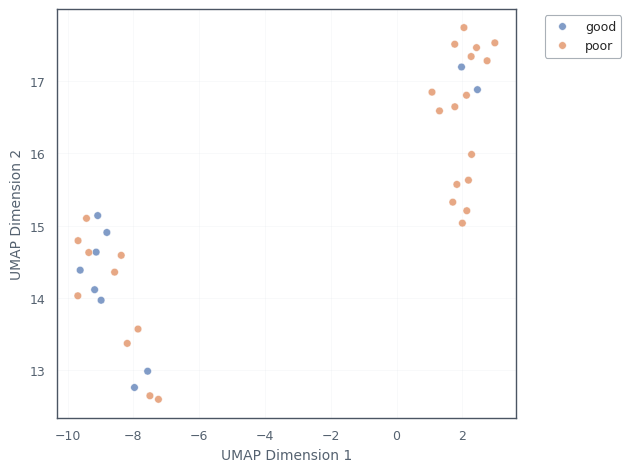

In [ ]:
# UMAP on Brain SHAP values
brain_proteomes = prot_mlmarker_df_filtered[['index', 'Brain', 'filename', 'disease_status']]
brain_proteomes = brain_proteomes.pivot_table(
    index=['filename', 'disease_status'], 
    columns='index', 
    values='Brain'
).reset_index()

reducer = umap.UMAP()
x = brain_proteomes.copy().set_index('filename').drop(columns=['disease_status'])
embedding_prot = reducer.fit_transform(x.fillna(0))

embedding_prot_df = pd.DataFrame(embedding_prot)
embedding_prot_df['filename'] = x.index
embedding_prot_df['disease_status'] = embedding_prot_df['filename'].str.split('_').str[0]

f = sns.scatterplot(
    data=embedding_prot_df, 
    x=embedding_prot_df[0], 
    y=embedding_prot_df[1], 
    hue='disease_status', 
    s=30, 
    alpha=0.7
)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

f.figure.savefig('../Figures_paper/melanoma_umap_original_proteins.png', dpi=800, bbox_inches='tight')

In [ ]:
all_samples = brain_proteomes.filename.unique

## Cluster-Grouped Protein SHAP Analysis

In [ ]:
# Assign cluster labels to proteins
prot_mlmarker_df_filtered['cluster_label'] = prot_mlmarker_df_filtered['filename'].apply(
    lambda x: 'poor_brain' if x in poor_brain 
    else ('poor_notbrain' if x in poor_notbrain 
    else ('good_notbrain' if x in good_notbrain else 'good_brain'))
)
prot_mlmarker_df_filtered['predicted'] = prot_mlmarker_df_filtered['cluster_label'].str.split('_').str[-1]

# Group by cluster and index, compute mean SHAP values
cluster_grouped_protein_shaps = prot_mlmarker_df_filtered.drop(
    columns=['PXD_folder', 'filename', 'disease_status', 'predicted', 'cluster']
).groupby(['cluster_label', 'index']).mean()

print("Cluster shapes:")
for cluster in ['good_brain', 'good_notbrain', 'poor_brain', 'poor_notbrain']:
    print(f"  {cluster}: {cluster_grouped_protein_shaps.loc[cluster].shape}")

Cluster shapes:
  good_brain: (2370, 34)
  good_notbrain: (1984, 34)
  poor_brain: (3324, 34)
  poor_notbrain: (3128, 34)


## SHAP Value Distribution per Subpopulation

In [ ]:
# Prepare data for boxplot
df_reset = cluster_grouped_protein_shaps.reset_index()
df_reset = df_reset.drop(columns=["index"])
df_melted = df_reset.melt(id_vars=["cluster_label"], var_name="Tissue", value_name="Expression")
df_melted = df_melted[df_melted['Tissue']=='Brain']


STATISTICAL TESTS: Brain vs Not-Brain SHAP Values

Data Summary:
   All values:
      Brain samples: n=5694, zeros=4469 (78.5%)
      Not-Brain samples: n=5112, zeros=4023 (78.7%)
      Brain-predicted (n=5694):
         Median: 0.000000
         Mean:   0.000210
         Std:    0.002856
      Not-Brain-predicted (n=5112):
         Median: 0.000000
         Mean:   0.000012
         Std:    0.000416

----------------------------------------------------------------------
Mann-Whitney U Tests (comparing medians/ranks):
----------------------------------------------------------------------

1. One-sided (H1: Brain > Not-Brain):
      U = 15491840.00, p = 3.36e-16
      ✓ Significant (α=0.05)

2. One-sided (H1: Brain < Not-Brain):
      U = 15491840.00, p = 1.00e+00
      ✗ Not significant (α=0.05)

3. Two-sided (H1: Brain ≠ Not-Brain):
      U = 15491840.00, p = 6.73e-16
      ✓ Significant (α=0.05)

----------------------------------------------------------------------
Kolmogorov-Smirno

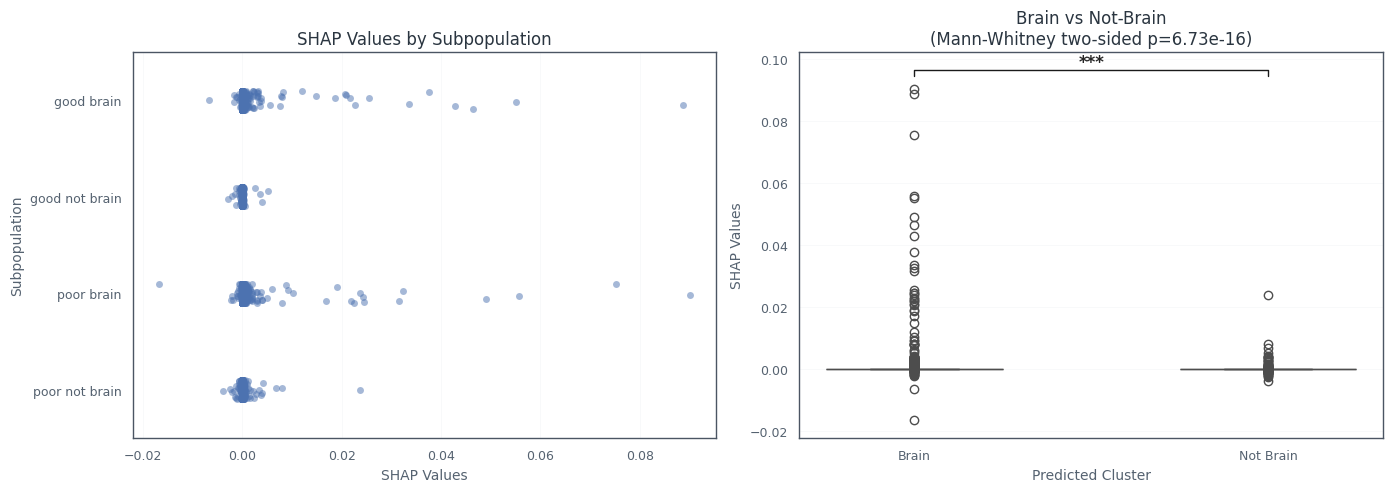


Figure saved: ../Figures_review/Fig4.png


In [ ]:
from scipy import stats

# Create a simplified cluster label (brain vs notbrain)
df_melted['predicted_cluster'] = df_melted['cluster_label'].apply(
    lambda x: 'Brain' if 'brain' in x and 'notbrain' not in x else 'Not Brain'
)

# Separate the data by predicted cluster
brain_shap = df_melted[df_melted['predicted_cluster'] == 'Brain']['Expression']
notbrain_shap = df_melted[df_melted['predicted_cluster'] == 'Not Brain']['Expression']


brain_shap = df_melted[df_melted['predicted_cluster'] == 'Brain']['Expression']
notbrain_shap = df_melted[df_melted['predicted_cluster'] == 'Not Brain']['Expression']

# 1. Mann-Whitney U test (one-sided: Brain > Not-Brain)
stat_greater, p_greater = stats.mannwhitneyu(brain_shap, notbrain_shap, alternative='greater')
# 2. Mann-Whitney U test (one-sided: Brain < Not-Brain)
stat_less, p_less = stats.mannwhitneyu(brain_shap, notbrain_shap, alternative='less')
# 3. Mann-Whitney U test (two-sided)
stat_twosided, p_twosided = stats.mannwhitneyu(brain_shap, notbrain_shap, alternative='two-sided')
# 4. Kolmogorov-Smirnov test (distribution difference)
ks_stat, ks_p = stats.ks_2samp(brain_shap, notbrain_shap)

print("="*70)
print("STATISTICAL TESTS: Brain vs Not-Brain SHAP Values")
print("="*70)
print(f"\nData Summary:")
print(f"   All values:")
print(f"      Brain samples: n={len(brain_shap)}, zeros={sum(brain_shap==0)} ({100*sum(brain_shap==0)/len(brain_shap):.1f}%)")
print(f"      Not-Brain samples: n={len(notbrain_shap)}, zeros={sum(notbrain_shap==0)} ({100*sum(notbrain_shap==0)/len(notbrain_shap):.1f}%)")
print(f"      Brain-predicted (n={len(brain_shap)}):")
print(f"         Median: {brain_shap.median():.6f}")
print(f"         Mean:   {brain_shap.mean():.6f}")
print(f"         Std:    {brain_shap.std():.6f}")
print(f"      Not-Brain-predicted (n={len(notbrain_shap)}):")
print(f"         Median: {notbrain_shap.median():.6f}")
print(f"         Mean:   {notbrain_shap.mean():.6f}")
print(f"         Std:    {notbrain_shap.std():.6f}")

print(f"\n" + "-"*70)
print("Mann-Whitney U Tests (comparing medians/ranks):")
print("-"*70)
print(f"\n1. One-sided (H1: Brain > Not-Brain):")
print(f"      U = {stat_greater:.2f}, p = {p_greater:.2e}")
print(f"      {'✓ Significant' if p_greater < 0.05 else '✗ Not significant'} (α=0.05)")

print(f"\n2. One-sided (H1: Brain < Not-Brain):")
print(f"      U = {stat_less:.2f}, p = {p_less:.2e}")
print(f"      {'✓ Significant' if p_less < 0.05 else '✗ Not significant'} (α=0.05)")

print(f"\n3. Two-sided (H1: Brain ≠ Not-Brain):")
print(f"      U = {stat_twosided:.2f}, p = {p_twosided:.2e}")
print(f"      {'✓ Significant' if p_twosided < 0.05 else '✗ Not significant'} (α=0.05)")

print(f"\n" + "-"*70)
print("Kolmogorov-Smirnov Test (comparing distributions):")
print("-"*70)
print(f"\n4. KS Test (H1: distributions differ):")
print(f"      KS statistic = {ks_stat:.4f}, p = {ks_p:.2e}")
print(f"      {'✓ Distributions significantly different' if ks_p < 0.05 else '✗ Distributions not significantly different'} (α=0.05)")

print(f"\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
if p_greater < 0.05:
    print("→ Brain-predicted samples have HIGHER SHAP values than Not-Brain samples")
elif p_less < 0.05:
    print("→ Brain-predicted samples have LOWER SHAP values than Not-Brain samples")
else:
    print("→ No significant difference in SHAP value magnitude between groups")

if ks_p < 0.05:
    print("→ The SHAP value distributions are significantly different between groups")

# Create figure with four panels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Stripplot by subpopulation (non-zero values only)
ax1 = axes[0]
sns.stripplot(
    data=df_melted,
    y="cluster_label", 
    x="Expression", 
    alpha=0.5, 
    jitter=True,
    ax=ax1
)
ax1.set_xlabel("SHAP Values")
ax1.set_ylabel("Subpopulation")
ax1.set_title('SHAP Values by Subpopulation')
ax1.set_yticks(range(len(ax1.get_yticklabels())))
labels = [label.get_text().replace('_', ' ').replace('notbrain', 'not brain') for label in ax1.get_yticklabels()]
ax1.set_yticklabels(labels)

# Panel 2: Boxplot comparing Brain vs Not-Brain (non-zero only)
ax2 = axes[1]
cluster_colors = {'Brain': COLORS['primary'], 'Not Brain': COLORS['secondary']}
sns.boxplot(
    data=df_melted, 
    x='predicted_cluster', 
    y='Expression',
    hue='predicted_cluster',
    palette=cluster_colors,
    ax=ax2,
    width=0.5,
    order=['Brain', 'Not Brain'],
    legend=False
)
ax2.set_xlabel('Predicted Cluster')
ax2.set_ylabel('SHAP Values')
ax2.set_title(f'Brain vs Not-Brain\n(Mann-Whitney two-sided p={p_twosided:.2e})')

# Add significance annotation
y_max = df_melted['Expression'].max()
y_annotation = y_max * 1.05
ax2.plot([0, 0, 1, 1], [y_annotation, y_annotation*1.02, y_annotation*1.02, y_annotation], 
         'k-', linewidth=1)
sig_text = '***' if p_twosided < 0.001 else ('**' if p_twosided < 0.01 else ('*' if p_twosided < 0.05 else 'ns'))
ax2.text(0.5, y_annotation*1.03, sig_text, ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../Figures_review/Fig4.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved: ../Figures_review/Fig4.png")

# Dynamic Range Analysis

This section analyzes whether sample dynamic range (total protein abundance) or MLMarker feature coverage correlates with brain prediction scores. This is important to ensure that the brain similarity differences between good and poor responders are not simply artifacts of technical variation in sample quality.

In [ ]:
all_samples = brain_proteomes.filename.tolist()

In [ ]:
entire_df = pd.DataFrame()
for s in tqdm.tqdm(list(all_samples)):
    path = f"/public/conode56/conode53_pride/PRIDE_DATA/PXD007592/IONBOT_v0.11.0/{s}/ionbot.first.csv"
    lengths_path = "/home/tine/git/Publication/MLMarker-manuscript/uniprot_reviewed_lengths.tsv"
    file = pd.read_csv(path)
    lenghts_df = pd.read_csv(lengths_path, sep='\t')
    file_df = ionbot_first_to_prot_quant(file, lenghts_df)
    file_df['filename'] = s
    entire_df = pd.concat([entire_df, file_df])

saf_entire_df = entire_df.pivot_table(index='filename', columns='proteins', values='SAF', aggfunc='sum').fillna(0)
print(f"Loaded SAF data: {saf_entire_df.shape}")

100%|██████████| 36/36 [00:06<00:00,  5.22it/s]

Loaded SAF data: (36, 6995)


## Dynamic Range Analysis: Technical Metrics vs Brain Prediction

Test whether brain prediction scores correlate with technical metrics (total protein abundance, feature coverage). 
We use **Pearson correlation** to assess linear relationships between continuous variables, which is more appropriate 
than Mann-Whitney for testing whether predictions are artifacts of technical variation.

In [ ]:
tissue_preds = pd.read_csv('/home/tine/git/Publication/MLMarker-manuscript/PXD007592_responders_melanoma/mlmarker_tissue_predictions.csv')

Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


TECHNICAL METRICS: Do they predict Brain vs Not-Brain?

1. Dynamic Range (Summed SAF):
   Brain cluster:     median = 6.94e+01
   Not-Brain cluster: median = 4.83e+01
   Mann-Whitney U p = 0.0015 ⚠
   Point-biserial r = 0.548, p = 0.0005 ⚠
   ROC-AUC = 0.830 (good discrimination)

2. Feature Coverage (MLMarker features detected):
   Brain cluster:     median = 1974
   Not-Brain cluster: median = 1852
   Mann-Whitney U p = 0.7754 ✓
   Point-biserial r = 0.267, p = 0.1154 ✓
   ROC-AUC = 0.531 (no discrimination ≈ 0.5)


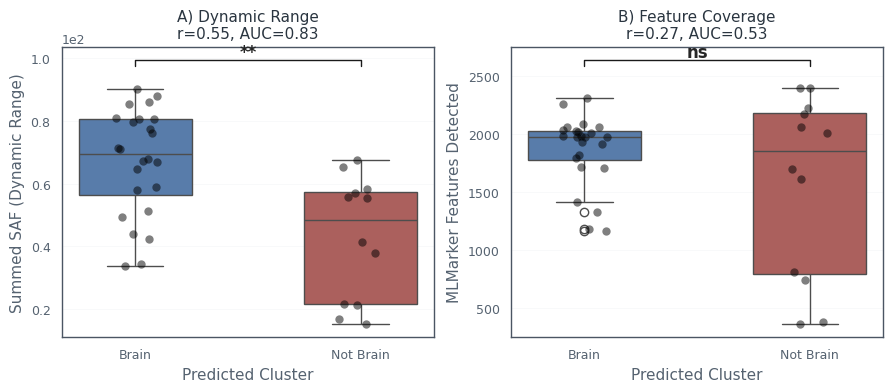


CONCLUSION
⚠ Some association detected. Review the metrics above.

Figure saved: ../Figures_review/dynamic_range_analysis.png


In [ ]:
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.metrics import roc_auc_score
import matplotlib.patches as mpatches

# Prepare data
brain_color = COLORS['primary']
notbrain_color = COLORS['secondary']

# Get model features
model = mlmarker.MLMarker()
features = model.get_model_features()
found_features = set(features).intersection(set(saf_entire_df.columns))

# Add cluster information to samples
correlation_df = pd.DataFrame({
    'filename': saf_entire_df.index,
    'summedSAF': saf_entire_df.sum(axis=1).values,
    'features': saf_entire_df[list(found_features)].astype(bool).sum(axis=1).values
})
correlation_df = correlation_df.merge(tissue_preds[['Brain', 'filename']], on='filename')
correlation_df['Cluster'] = correlation_df['filename'].apply(
    lambda x: 'Brain' if x in set(poor_brain) | set(good_brain) else 'Not Brain'
)
# Binary encoding for correlation/AUC (1 = Brain, 0 = Not Brain)
correlation_df['Cluster_binary'] = (correlation_df['Cluster'] == 'Brain').astype(int)

# Statistical tests
brain_cluster = correlation_df[correlation_df['Cluster'] == 'Brain']
notbrain_cluster = correlation_df[correlation_df['Cluster'] == 'Not Brain']

# Mann-Whitney U (group comparison)
stat_saf, p_saf = mannwhitneyu(brain_cluster['summedSAF'], notbrain_cluster['summedSAF'], alternative='two-sided')
stat_feat, p_feat = mannwhitneyu(brain_cluster['features'], notbrain_cluster['features'], alternative='two-sided')

# Point-biserial correlation (correlation between continuous and binary)
r_pb_saf, p_pb_saf = pointbiserialr(correlation_df['Cluster_binary'], correlation_df['summedSAF'])
r_pb_feat, p_pb_feat = pointbiserialr(correlation_df['Cluster_binary'], correlation_df['features'])

# ROC-AUC: Can SAF/features predict cluster membership? (AUC ≈ 0.5 = no discrimination)
auc_saf = roc_auc_score(correlation_df['Cluster_binary'], correlation_df['summedSAF'])
auc_feat = roc_auc_score(correlation_df['Cluster_binary'], correlation_df['features'])

print("="*70)
print("TECHNICAL METRICS: Do they predict Brain vs Not-Brain?")
print("="*70)
print(f"\n1. Dynamic Range (Summed SAF):")
print(f"   Brain cluster:     median = {brain_cluster['summedSAF'].median():.2e}")
print(f"   Not-Brain cluster: median = {notbrain_cluster['summedSAF'].median():.2e}")
print(f"   Mann-Whitney U p = {p_saf:.4f} {'⚠' if p_saf < 0.05 else '✓'}")
print(f"   Point-biserial r = {r_pb_saf:.3f}, p = {p_pb_saf:.4f} {'⚠' if p_pb_saf < 0.05 else '✓'}")
print(f"   ROC-AUC = {auc_saf:.3f} {'(good discrimination)' if abs(auc_saf - 0.5) > 0.2 else '(no discrimination ≈ 0.5)'}")

print(f"\n2. Feature Coverage (MLMarker features detected):")
print(f"   Brain cluster:     median = {brain_cluster['features'].median():.0f}")
print(f"   Not-Brain cluster: median = {notbrain_cluster['features'].median():.0f}")
print(f"   Mann-Whitney U p = {p_feat:.4f} {'⚠' if p_feat < 0.05 else '✓'}")
print(f"   Point-biserial r = {r_pb_feat:.3f}, p = {p_pb_feat:.4f} {'⚠' if p_pb_feat < 0.05 else '✓'}")
print(f"   ROC-AUC = {auc_feat:.3f} {'(good discrimination)' if abs(auc_feat - 0.5) > 0.2 else '(no discrimination ≈ 0.5)'}")

# Create combined figure (1x2 layout)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

cluster_colors = {'Brain': brain_color, 'Not Brain': notbrain_color}

# Panel A: Dynamic Range by Cluster
ax1 = axes[0]
sns.boxplot(data=correlation_df, x='Cluster', y='summedSAF', hue='Cluster',
            palette=cluster_colors, ax=ax1, width=0.5, order=['Brain', 'Not Brain'], legend=False)
sns.stripplot(data=correlation_df, x='Cluster', y='summedSAF', 
              color='black', alpha=0.5, ax=ax1, size=6, order=['Brain', 'Not Brain'])
ax1.set_xlabel('Predicted Cluster', fontsize=11)
ax1.set_ylabel('Summed SAF (Dynamic Range)', fontsize=11)
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Add stats annotation
y_max = correlation_df['summedSAF'].max()
y_annotation = y_max * 1.08
ax1.plot([0, 0, 1, 1], [y_annotation, y_annotation*1.02, y_annotation*1.02, y_annotation], 'k-', linewidth=1)
sig_text = 'ns' if p_saf >= 0.05 else ('*' if p_saf >= 0.01 else ('**' if p_saf >= 0.001 else '***'))
ax1.text(0.5, y_annotation*1.03, sig_text, ha='center', fontsize=12, fontweight='bold')
ax1.set_title(f'A) Dynamic Range\nr={r_pb_saf:.2f}, AUC={auc_saf:.2f}', fontsize=11)

# Panel B: Feature Coverage by Cluster
ax2 = axes[1]
sns.boxplot(data=correlation_df, x='Cluster', y='features', hue='Cluster',
            palette=cluster_colors, ax=ax2, width=0.5, order=['Brain', 'Not Brain'], legend=False)
sns.stripplot(data=correlation_df, x='Cluster', y='features', 
              color='black', alpha=0.5, ax=ax2, size=6, order=['Brain', 'Not Brain'])
ax2.set_xlabel('Predicted Cluster', fontsize=11)
ax2.set_ylabel('MLMarker Features Detected', fontsize=11)

# Add stats annotation
y_max2 = correlation_df['features'].max()
y_annotation2 = y_max2 * 1.08
ax2.plot([0, 0, 1, 1], [y_annotation2, y_annotation2*1.02, y_annotation2*1.02, y_annotation2], 'k-', linewidth=1)
sig_text2 = 'ns' if p_feat >= 0.05 else ('*' if p_feat >= 0.01 else ('**' if p_feat >= 0.001 else '***'))
ax2.text(0.5, y_annotation2*1.03, sig_text2, ha='center', fontsize=12, fontweight='bold')
ax2.set_title(f'B) Feature Coverage\nr={r_pb_feat:.2f}, AUC={auc_feat:.2f}', fontsize=11)

plt.tight_layout()
plt.savefig('../Figures_review/dynamic_range_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("CONCLUSION")
print("="*70)
no_confound = (p_saf >= 0.05 and p_feat >= 0.05 and 
               abs(r_pb_saf) < 0.3 and abs(r_pb_feat) < 0.3 and
               abs(auc_saf - 0.5) < 0.2 and abs(auc_feat - 0.5) < 0.2)
if no_confound:
    print("✓ No association between technical metrics and brain prediction:")
    print("  - Non-significant group differences (Mann-Whitney p > 0.05)")
    print("  - Weak correlations (|r| < 0.3)")
    print("  - Poor discrimination (AUC ≈ 0.5)")
    print("  → Brain predictions are NOT artifacts of dynamic range or coverage.")
else:
    print("⚠ Some association detected. Review the metrics above.")

print(f"\nFigure saved: ../Figures_review/dynamic_range_analysis.png")

In [ ]:
df = pd.read_csv('/home/tine/git/Publication/MLMarker-manuscript/PXD007592_responders_melanoma/QuantifiedProteins.tsv', sep='\t')
df.head()

,Protein Groups,Gene Name,Organism,Intensity good_responder_1_1,Intensity good_responder_1_2,Intensity good_responder_2_1,Intensity good_responder_2_2,Intensity good_responder_3_1,Intensity good_responder_3_2,Intensity good_responder_4_1,...,Intensity poor_responder_5_1,Intensity poor_responder_5_2,Intensity poor_responder_6_1,Intensity poor_responder_6_2,Intensity poor_responder_7_1,Intensity poor_responder_7_2,Intensity poor_responder_8_1,Intensity poor_responder_8_2,Intensity poor_responder_9_1,Intensity poor_responder_9_2
0,1433E_HUMAN,NaN,NaN,3.310385e+07,2.419982e+07,4.259672e+07,3.735999e+07,4.879881e+08,4.983080e+08,2.358096e+07,...,1.706572e+08,1.479368e+08,2.511457e+08,2.393805e+08,4.352050e+08,3.424619e+08,2.067065e+08,2.096162e+08,2.669441e+08,2.885599e+08
1,1433F_HUMAN,NaN,NaN,1.774740e+06,2.207387e+06,7.425527e+06,5.042727e+06,9.849733e+07,8.432613e+07,5.120667e+06,...,2.844512e+06,1.141057e+07,6.349508e+06,1.900698e+07,6.234470e+07,7.083404e+07,3.013392e+07,3.069074e+07,3.804948e+07,3.871897e+07
2,1433G_HUMAN,NaN,NaN,1.095021e+06,2.564823e+06,6.293428e+06,7.343138e+06,9.792576e+07,9.554236e+07,4.496359e+06,...,8.093105e+06,1.590415e+07,1.342786e+07,2.271512e+07,7.857671e+07,1.345636e+08,4.760817e+07,4.593734e+07,4.839000e+07,5.499813e+07
3,1433S_HUMAN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,1433T_HUMAN,NaN,NaN,0.000000e+00,0.000000e+00,1.976730e+07,1.366726e+07,1.003937e+08,8.751298e+07,1.514065e+07,...,4.603665e+07,3.822686e+07,5.974924e+07,5.330161e+07,1.128929e+08,8.556700e+07,4.277093e+07,4.584936e+07,1.147371e+08,7.921284e+07


In [ ]:
# Load QuantifiedProteins and ID mapping
quant_df = pd.read_csv('/home/tine/git/Publication/MLMarker-manuscript/PXD007592_responders_melanoma/QuantifiedProteins.tsv', sep='\t')
idmapping = pd.read_csv('/home/tine/git/Publication/MLMarker-manuscript/idmapping_2025_07_28.tsv', sep='\t')

# Create mapping from Entry Name (e.g., 1433E_HUMAN) to UniProt accession (e.g., P62258)
name_to_accession = dict(zip(idmapping['Entry Name'], idmapping['Entry']))

# Map protein groups to accessions
quant_df['UniProt'] = quant_df['Protein Groups'].map(name_to_accession)
print(f"Mapped {quant_df['UniProt'].notna().sum()} / {len(quant_df)} proteins to UniProt accessions")

# Get intensity columns
intensity_cols = [c for c in quant_df.columns if c.startswith('Intensity ')]
print(f"Found {len(intensity_cols)} intensity columns")

# Pivot to protein x sample matrix (using UniProt accessions)
quant_pivot = quant_df[quant_df['UniProt'].notna()].set_index('UniProt')[intensity_cols].T
quant_pivot.index = quant_pivot.index.str.replace('Intensity ', '')

# Map sample names to match subpopulations format
# Sample format in quant: "good_responder_1_1" -> need to match with filenames
print(f"\nQuantified data shape: {quant_pivot.shape}")
print(f"Sample names: {quant_pivot.index.tolist()[:5]}...")

# Check overlap with MLMarker features
model = mlmarker.MLMarker()
mlmarker_features = set(model.get_model_features())
quant_features = set(quant_pivot.columns)
overlap = mlmarker_features.intersection(quant_features)
print(f"\nMLMarker features: {len(mlmarker_features)}")
print(f"QuantifiedProteins features: {len(quant_features)}")
print(f"Overlap: {len(overlap)} proteins ({100*len(overlap)/len(mlmarker_features):.1f}% of MLMarker features)")

Mapped 4899 / 6642 proteins to UniProt accessions
Found 36 intensity columns

Quantified data shape: (36, 4899)
Sample names: ['good_responder_1_1', 'good_responder_1_2', 'good_responder_2_1', 'good_responder_2_2', 'good_responder_3_1']...


Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations



MLMarker features: 5979
QuantifiedProteins features: 4899
Overlap: 2935 proteins (49.1% of MLMarker features)


INTENSITY CONFOUNDING ANALYSIS: Brain vs Not-Brain

Samples: Brain (n=24), Not-Brain (n=12)
MLMarker features: 2935, Non-MLMarker: 1964

Metric                         Brain           Not-Brain       p-value    r       
----------------------------------------------------------------------
All proteins intensity         7.02e+10 4.74e+10 0.0124     0.42    
MLMarker intensity             4.05e+10 2.98e+10 0.0197     0.40    
Non-MLMarker intensity         2.97e+10 1.99e+10 0.0069     0.43    
MLMarker features detected     1557 1447 0.7372     0.29    
MLMarker proportion            56.7% 58.3% 0.2609    

Global intensity correlation (MLMarker vs Non-MLMarker): r = 0.976


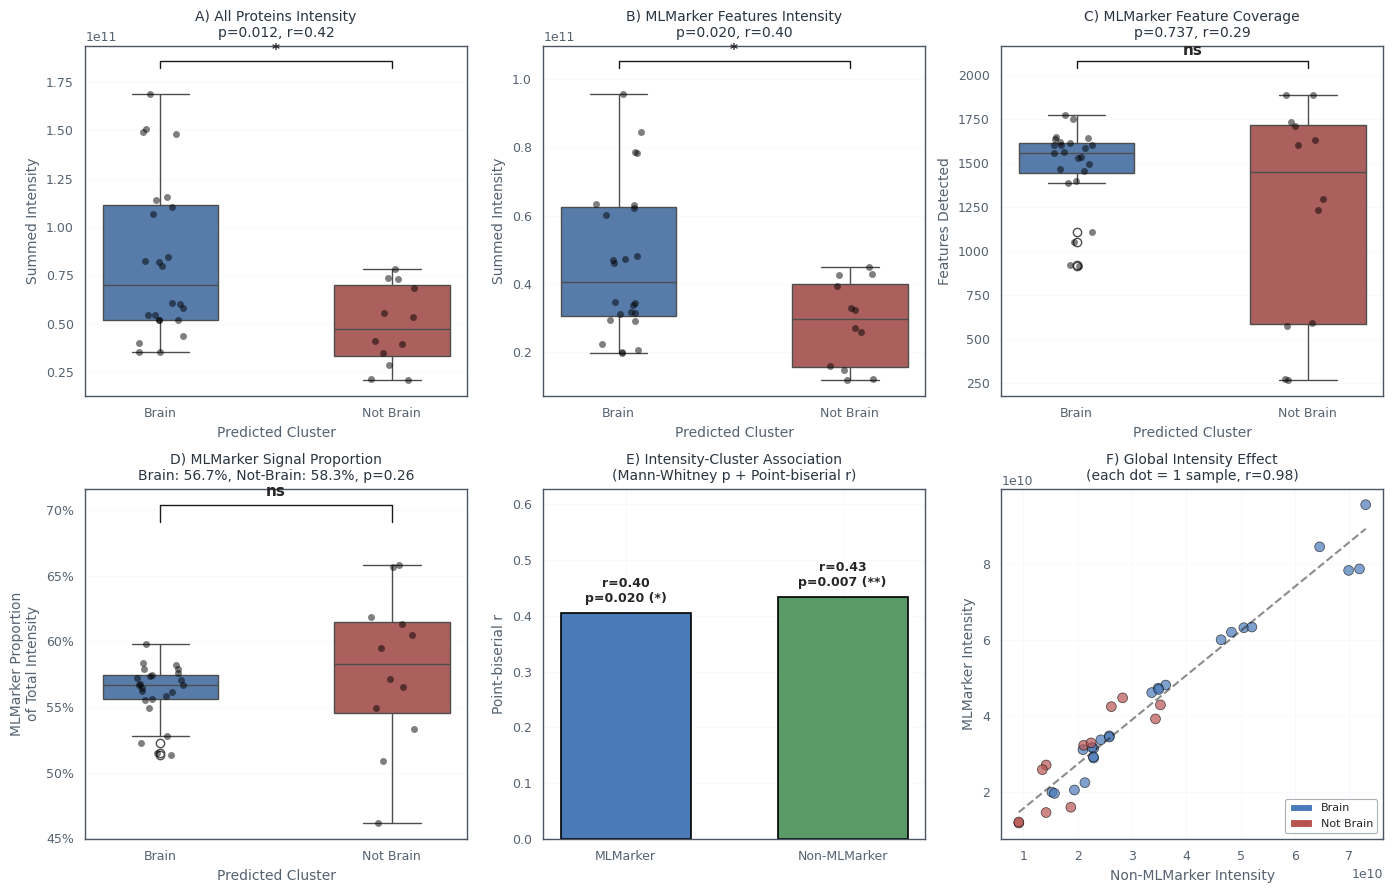


CONCLUSION
• Intensity correlates with cluster for ALL protein sets (r≈0.40-0.43)
• Non-MLMarker proteins show equal/stronger correlation (r=0.43) vs MLMarker (r=0.40)
• MLMarker proportion is NOT enriched in Brain cluster (56.7% vs 58.3%, p=0.26)
• Global correlation between feature sets: r=0.98
→ Intensity effect is GLOBAL, not MLMarker-specific. Brain predictions are NOT artifacts.

Figure saved: ../Figures_review/intensity_confounding_analysis.png


In [ ]:
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.metrics import roc_auc_score
from matplotlib.patches import Patch

# Prepare data
brain_color = COLORS['primary']
notbrain_color = COLORS['secondary']
overlap_features = list(overlap)
non_mlmarker_features = list(set(quant_pivot.columns) - set(overlap_features))

# Calculate intensities for different feature sets
intensity_all = quant_pivot.sum(axis=1)
intensity_mlmarker = quant_pivot[overlap_features].sum(axis=1)
intensity_nonmlmarker = quant_pivot[non_mlmarker_features].sum(axis=1)
feature_count = quant_pivot[overlap_features].astype(bool).sum(axis=1)

# Create analysis dataframe
quant_correlation_df = pd.DataFrame({
    'sample': quant_pivot.index,
    'intensity_all': intensity_all.values,
    'intensity_mlmarker': intensity_mlmarker.values,
    'intensity_nonmlmarker': intensity_nonmlmarker.values,
    'features': feature_count.values
})

# Calculate MLMarker proportion of total intensity
quant_correlation_df['mlmarker_proportion'] = quant_correlation_df['intensity_mlmarker'] / quant_correlation_df['intensity_all']

# Map samples to clusters
def get_cluster_v2(sample_name):
    parts = sample_name.split('_')
    resp_type = parts[0]
    resp_num = parts[2]
    pattern = f"{resp_type}_responder_{resp_num}"
    for filename in poor_brain + good_brain:
        if pattern in filename:
            return 'Brain'
    for filename in poor_notbrain + good_notbrain:
        if pattern in filename:
            return 'Not Brain'
    return None

quant_correlation_df['Cluster'] = quant_correlation_df['sample'].apply(get_cluster_v2)
quant_corr_valid = quant_correlation_df[quant_correlation_df['Cluster'].notna()].copy()
quant_corr_valid['Cluster_binary'] = (quant_corr_valid['Cluster'] == 'Brain').astype(int)

# Separate clusters
brain_cluster = quant_corr_valid[quant_corr_valid['Cluster'] == 'Brain']
notbrain_cluster = quant_corr_valid[quant_corr_valid['Cluster'] == 'Not Brain']

# Statistical tests
stat_all, p_all = mannwhitneyu(brain_cluster['intensity_all'], notbrain_cluster['intensity_all'], alternative='two-sided')
stat_mlm, p_mlm = mannwhitneyu(brain_cluster['intensity_mlmarker'], notbrain_cluster['intensity_mlmarker'], alternative='two-sided')
stat_non, p_non = mannwhitneyu(brain_cluster['intensity_nonmlmarker'], notbrain_cluster['intensity_nonmlmarker'], alternative='two-sided')
stat_feat, p_feat = mannwhitneyu(brain_cluster['features'], notbrain_cluster['features'], alternative='two-sided')
stat_prop, p_prop = mannwhitneyu(brain_cluster['mlmarker_proportion'], notbrain_cluster['mlmarker_proportion'], alternative='two-sided')

r_all, _ = pointbiserialr(quant_corr_valid['Cluster_binary'], quant_corr_valid['intensity_all'])
r_mlm, _ = pointbiserialr(quant_corr_valid['Cluster_binary'], quant_corr_valid['intensity_mlmarker'])
r_non, _ = pointbiserialr(quant_corr_valid['Cluster_binary'], quant_corr_valid['intensity_nonmlmarker'])
r_feat, _ = pointbiserialr(quant_corr_valid['Cluster_binary'], quant_corr_valid['features'])

# Correlation between MLMarker and non-MLMarker intensities (global effect)
r_global = quant_corr_valid['intensity_mlmarker'].corr(quant_corr_valid['intensity_nonmlmarker'])

# Print results
print("="*70)
print("INTENSITY CONFOUNDING ANALYSIS: Brain vs Not-Brain")
print("="*70)
print(f"\nSamples: Brain (n={len(brain_cluster)}), Not-Brain (n={len(notbrain_cluster)})")
print(f"MLMarker features: {len(overlap_features)}, Non-MLMarker: {len(non_mlmarker_features)}")

print(f"\n{'Metric':<30} {'Brain':<15} {'Not-Brain':<15} {'p-value':<10} {'r':<8}")
print("-"*70)
print(f"{'All proteins intensity':<30} {brain_cluster['intensity_all'].median():.2e} {notbrain_cluster['intensity_all'].median():.2e} {p_all:<10.4f} {r_all:<8.2f}")
print(f"{'MLMarker intensity':<30} {brain_cluster['intensity_mlmarker'].median():.2e} {notbrain_cluster['intensity_mlmarker'].median():.2e} {p_mlm:<10.4f} {r_mlm:<8.2f}")
print(f"{'Non-MLMarker intensity':<30} {brain_cluster['intensity_nonmlmarker'].median():.2e} {notbrain_cluster['intensity_nonmlmarker'].median():.2e} {p_non:<10.4f} {r_non:<8.2f}")
print(f"{'MLMarker features detected':<30} {brain_cluster['features'].median():.0f} {notbrain_cluster['features'].median():.0f} {p_feat:<10.4f} {r_feat:<8.2f}")
print(f"{'MLMarker proportion':<30} {brain_cluster['mlmarker_proportion'].median():.1%} {notbrain_cluster['mlmarker_proportion'].median():.1%} {p_prop:<10.4f}")

print(f"\nGlobal intensity correlation (MLMarker vs Non-MLMarker): r = {r_global:.3f}")

# Create comprehensive figure with 6 panels (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
cluster_colors = {'Brain': brain_color, 'Not Brain': notbrain_color}

# Panel A: All proteins intensity
ax1 = axes[0, 0]
sns.boxplot(data=quant_corr_valid, x='Cluster', y='intensity_all', hue='Cluster',
            palette=cluster_colors, ax=ax1, width=0.5, order=['Brain', 'Not Brain'], legend=False)
sns.stripplot(data=quant_corr_valid, x='Cluster', y='intensity_all', 
              color='black', alpha=0.5, ax=ax1, size=5, order=['Brain', 'Not Brain'])
ax1.set_xlabel('Predicted Cluster', fontsize=10)
ax1.set_ylabel('Summed Intensity', fontsize=10)
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
y_max = quant_corr_valid['intensity_all'].max()
ax1.plot([0, 0, 1, 1], [y_max*1.08, y_max*1.10, y_max*1.10, y_max*1.08], 'k-', linewidth=1)
sig_text = 'ns' if p_all >= 0.05 else ('*' if p_all >= 0.01 else ('**' if p_all >= 0.001 else '***'))
ax1.text(0.5, y_max*1.12, sig_text, ha='center', fontsize=11, fontweight='bold')
ax1.set_title(f'A) All Proteins Intensity\np={p_all:.3f}, r={r_all:.2f}', fontsize=10)

# Panel B: MLMarker features intensity
ax2 = axes[0, 1]
sns.boxplot(data=quant_corr_valid, x='Cluster', y='intensity_mlmarker', hue='Cluster',
            palette=cluster_colors, ax=ax2, width=0.5, order=['Brain', 'Not Brain'], legend=False)
sns.stripplot(data=quant_corr_valid, x='Cluster', y='intensity_mlmarker', 
              color='black', alpha=0.5, ax=ax2, size=5, order=['Brain', 'Not Brain'])
ax2.set_xlabel('Predicted Cluster', fontsize=10)
ax2.set_ylabel('Summed Intensity', fontsize=10)
ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
y_max2 = quant_corr_valid['intensity_mlmarker'].max()
ax2.plot([0, 0, 1, 1], [y_max2*1.08, y_max2*1.10, y_max2*1.10, y_max2*1.08], 'k-', linewidth=1)
sig_text2 = 'ns' if p_mlm >= 0.05 else ('*' if p_mlm >= 0.01 else ('**' if p_mlm >= 0.001 else '***'))
ax2.text(0.5, y_max2*1.12, sig_text2, ha='center', fontsize=11, fontweight='bold')
ax2.set_title(f'B) MLMarker Features Intensity\np={p_mlm:.3f}, r={r_mlm:.2f}', fontsize=10)

# Panel C: MLMarker feature count (coverage)
ax3 = axes[0, 2]
sns.boxplot(data=quant_corr_valid, x='Cluster', y='features', hue='Cluster',
            palette=cluster_colors, ax=ax3, width=0.5, order=['Brain', 'Not Brain'], legend=False)
sns.stripplot(data=quant_corr_valid, x='Cluster', y='features', 
              color='black', alpha=0.5, ax=ax3, size=5, order=['Brain', 'Not Brain'])
ax3.set_xlabel('Predicted Cluster', fontsize=10)
ax3.set_ylabel('Features Detected', fontsize=10)
y_max3 = quant_corr_valid['features'].max()
ax3.plot([0, 0, 1, 1], [y_max3*1.08, y_max3*1.10, y_max3*1.10, y_max3*1.08], 'k-', linewidth=1)
sig_text3 = 'ns' if p_feat >= 0.05 else ('*' if p_feat >= 0.01 else ('**' if p_feat >= 0.001 else '***'))
ax3.text(0.5, y_max3*1.12, sig_text3, ha='center', fontsize=11, fontweight='bold')
ax3.set_title(f'C) MLMarker Feature Coverage\np={p_feat:.3f}, r={r_feat:.2f}', fontsize=10)

# Panel D: MLMarker proportion by cluster
ax4 = axes[1, 0]
sns.boxplot(data=quant_corr_valid, x='Cluster', y='mlmarker_proportion', hue='Cluster',
            palette=cluster_colors, ax=ax4, width=0.5, order=['Brain', 'Not Brain'], legend=False)
sns.stripplot(data=quant_corr_valid, x='Cluster', y='mlmarker_proportion',
              color='black', alpha=0.5, ax=ax4, size=5, order=['Brain', 'Not Brain'])
ax4.set_xlabel('Predicted Cluster', fontsize=10)
ax4.set_ylabel('MLMarker Proportion\nof Total Intensity', fontsize=10)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
y_max4 = quant_corr_valid['mlmarker_proportion'].max()
ax4.plot([0, 0, 1, 1], [y_max4*1.05, y_max4*1.07, y_max4*1.07, y_max4*1.05], 'k-', linewidth=1)
sig_text4 = 'ns' if p_prop >= 0.05 else ('*' if p_prop >= 0.01 else '**')
ax4.text(0.5, y_max4*1.08, sig_text4, ha='center', fontsize=11, fontweight='bold')
ax4.set_title(f'D) MLMarker Signal Proportion\nBrain: {brain_cluster["mlmarker_proportion"].median():.1%}, Not-Brain: {notbrain_cluster["mlmarker_proportion"].median():.1%}, p={p_prop:.2f}', fontsize=10)

# Panel E: Bar chart comparing correlations (showing both Mann-Whitney p and point-biserial r)
ax5 = axes[1, 1]
feature_sets = ['MLMarker', 'Non-MLMarker']
correlations = [r_mlm, r_non]
p_values_bar = [p_mlm, p_non]  # Mann-Whitney U p-values
bar_colors = [COLORS['primary'], COLORS['tertiary']]

bars = ax5.bar(feature_sets, correlations, color=bar_colors, edgecolor='black', linewidth=1.2, width=0.6)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax5.set_ylabel('Point-biserial r', fontsize=10)
ax5.set_ylim(0, max(correlations) * 1.45)

for bar, r, p in zip(bars, correlations, p_values_bar):
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'r={r:.2f}\np={p:.3f} ({sig})', ha='center', fontsize=9, fontweight='bold')

ax5.set_title(f'E) Intensity-Cluster Association\n(Mann-Whitney p + Point-biserial r)', fontsize=10)

# Panel F: Scatter showing global intensity correlation (each dot = sample)
ax6 = axes[1, 2]
scatter_colors = [brain_color if c == 'Brain' else notbrain_color for c in quant_corr_valid['Cluster']]
ax6.scatter(quant_corr_valid['intensity_nonmlmarker'], quant_corr_valid['intensity_mlmarker'], 
           c=scatter_colors, alpha=0.7, s=50, edgecolor='black', linewidth=0.5)
ax6.set_xlabel('Non-MLMarker Intensity', fontsize=10)
ax6.set_ylabel('MLMarker Intensity', fontsize=10)
ax6.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))

# Add regression line
z = np.polyfit(quant_corr_valid['intensity_nonmlmarker'], quant_corr_valid['intensity_mlmarker'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(quant_corr_valid['intensity_nonmlmarker'].min(), quant_corr_valid['intensity_nonmlmarker'].max(), 100)
ax6.plot(x_line, p_line(x_line), 'k--', alpha=0.5, linewidth=1.5)

legend_elements = [Patch(facecolor=brain_color, label='Brain'),
                   Patch(facecolor=notbrain_color, label='Not Brain')]
ax6.legend(handles=legend_elements, loc='lower right', fontsize=8)
ax6.set_title(f'F) Global Intensity Effect\n(each dot = 1 sample, r={r_global:.2f})', fontsize=10)

plt.tight_layout()
plt.savefig('../Figures_review/intensity_confounding_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("CONCLUSION")
print("="*70)
print(f"• Intensity correlates with cluster for ALL protein sets (r≈0.40-0.43)")
print(f"• Non-MLMarker proteins show equal/stronger correlation (r={r_non:.2f}) vs MLMarker (r={r_mlm:.2f})")
print(f"• MLMarker proportion is NOT enriched in Brain cluster ({brain_cluster['mlmarker_proportion'].median():.1%} vs {notbrain_cluster['mlmarker_proportion'].median():.1%}, p={p_prop:.2f})")
print(f"• Global correlation between feature sets: r={r_global:.2f}")
print(f"→ Intensity effect is GLOBAL, not MLMarker-specific. Brain predictions are NOT artifacts.")

print(f"\nFigure saved: ../Figures_review/intensity_confounding_analysis.png")

## Intensity Confounding Analysis

This analysis tests whether MLMarker's Brain cluster predictions could be artifacts of protein intensity variation rather than true biological signal. Each sample was assigned to Brain (n=24) or Not-Brain (n=12) clusters based on UMAP clustering of MLMarker tissue predictions.

**Panel A: All Proteins Intensity**  
Summed intensity across all 4,899 quantified proteins per sample. Tests whether Brain-classified samples simply have higher total protein abundance.

**Panel B: MLMarker Features Intensity**  
Summed intensity across the 2,935 MLMarker features detected in this dataset. Tests whether the intensity effect is specific to MLMarker's feature space.

**Panel C: MLMarker Feature Coverage**  
Number of MLMarker features detected (non-zero intensity) per sample. Tests whether Brain-classified samples have better proteome coverage that could bias predictions.

**Panel D: MLMarker Signal Proportion**  
Ratio of MLMarker feature intensity to total protein intensity per sample. Tests whether Brain-classified samples have enriched MLMarker-specific signal relative to the whole proteome. If MLMarker exploits intensity artifacts, this proportion should be higher in Brain samples.

**Panel E: Intensity-Cluster Correlation by Feature Set**  
Point-biserial correlation (r) between cluster assignment and summed intensity, calculated separately for MLMarker features (n=2,935) and non-MLMarker features (n=1,964). If the intensity effect were MLMarker-specific, only MLMarker features should show significant correlation.

**Panel F: Global Intensity Effect**  
Scatter plot showing MLMarker intensity vs non-MLMarker intensity per sample (each dot = one sample). The high correlation (r=0.98) demonstrates that intensity variation is a global sample-level effect affecting all proteins equally, not specific to MLMarker's feature space.